# **WEEK 1 :IoT Telemetry Ingestion and Signal Processing**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

In [ ]:
df = pd.read_csv("AI4I2020.zip")

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [ ]:
print("Shape :", df.shape)

print("\nColumns:\n")
print(df.columns)

print("\nInformation:\n")
df.info()

Shape : (10000, 14)

Columns:

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF

In [ ]:
print(df.isnull().sum())

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


In [ ]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [ ]:
df.drop_duplicates(inplace=True)

**Remove Unnecessary Columns :**

In [ ]:
df.drop(
    columns=["UDI", "Product ID"],
    inplace=True
)

**Encode Product Type :**

In [ ]:
encoder = LabelEncoder()

df["Type"] = encoder.fit_transform(df["Type"])

df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,2,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,1,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,1,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,1,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


# **Exploratory Data Analysis (EDA)**

Target Variable Distribution :

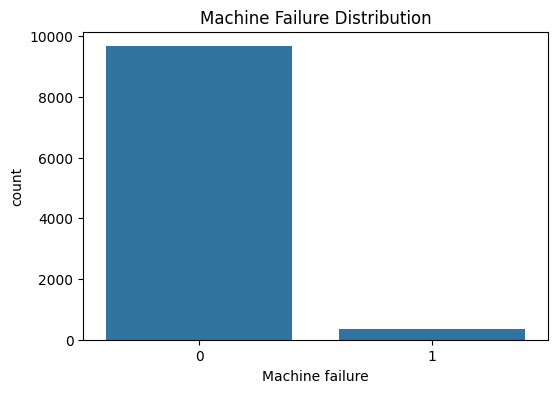

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,x="Machine failure")

plt.title("Machine Failure Distribution")

plt.show()

Failure Type Distribution:

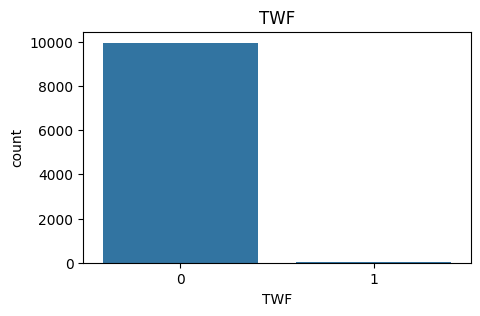

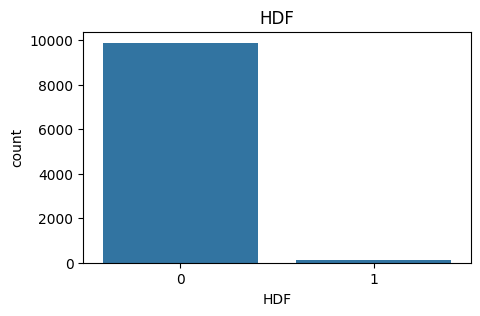

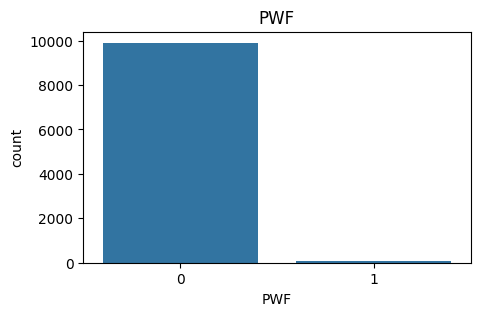

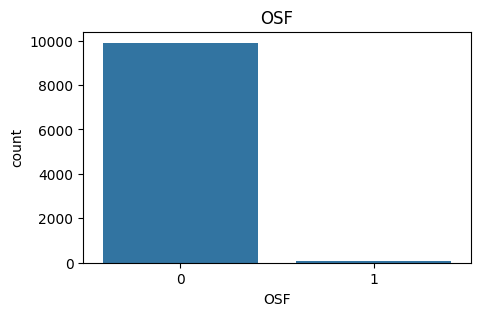

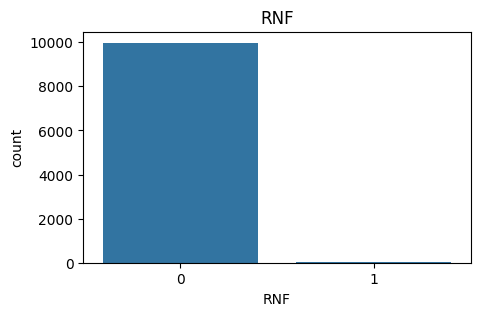

In [ ]:
failure_columns = ["TWF","HDF","PWF","OSF","RNF"]

for col in failure_columns:

    plt.figure(figsize=(5,3))

    sns.countplot(data=df,x=col)

    plt.title(col)

    plt.show()

Sensor Distribution :

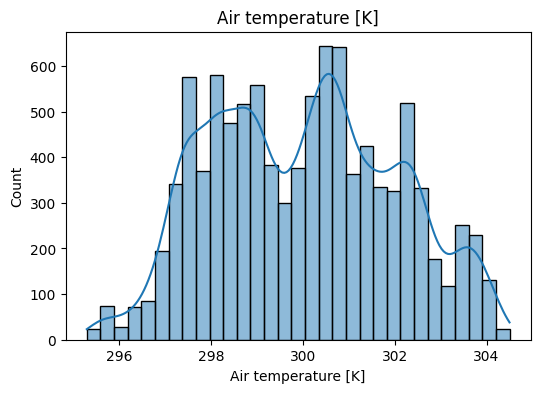

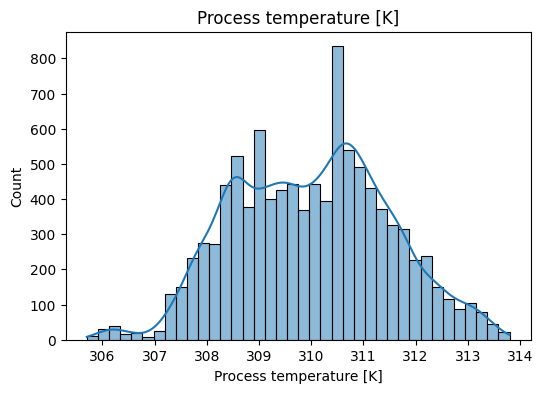

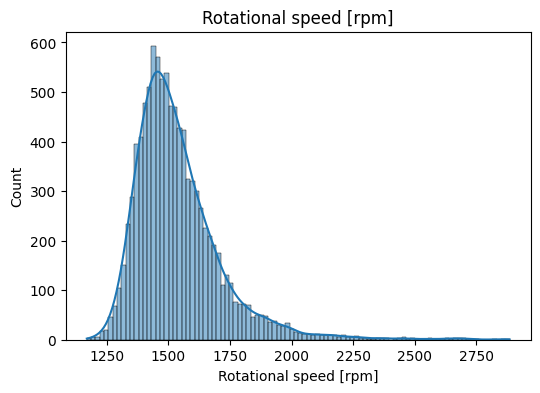

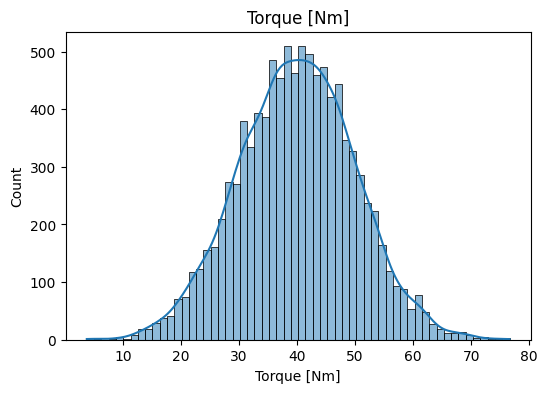

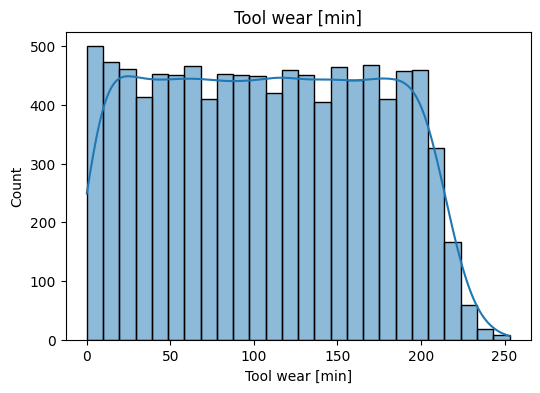

In [ ]:
sensor_columns = ["Air temperature [K]","Process temperature [K]","Rotational speed [rpm]","Torque [Nm]","Tool wear [min]"]

for col in sensor_columns:

    plt.figure(figsize=(6,4))

    sns.histplot(df[col],kde=True)

    plt.title(col)

    plt.show()

Boxplots :

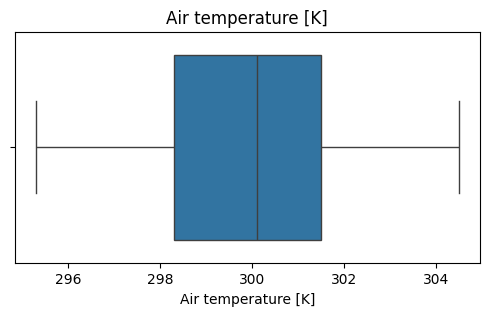

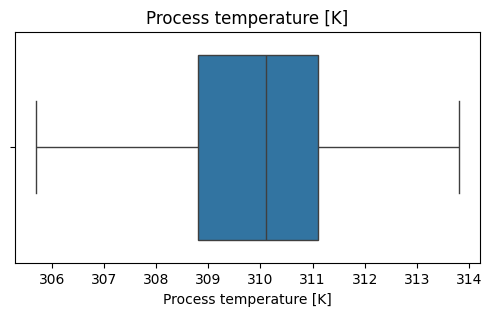

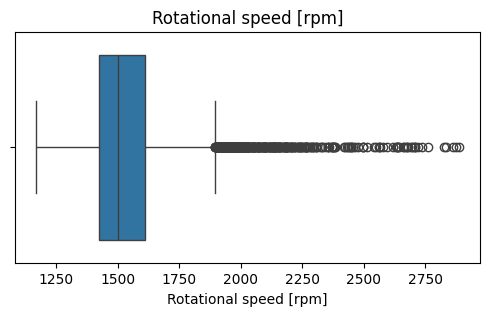

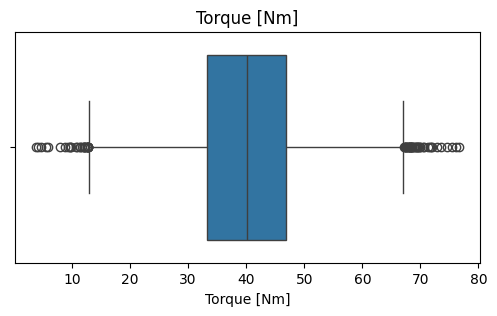

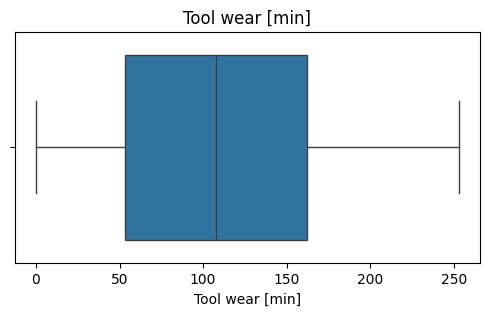

In [ ]:
for col in sensor_columns:

    plt.figure(figsize=(6,3))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

Correlation Heatmap :

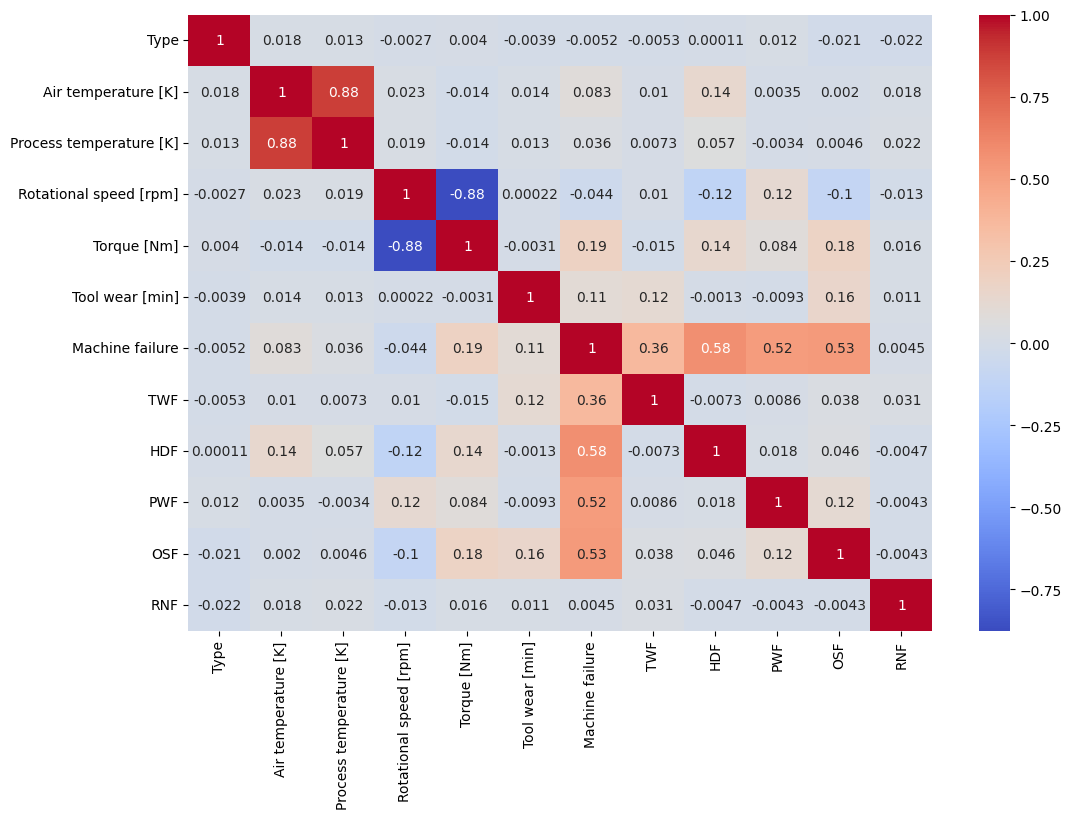

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

# Signal Processing

Rolling Mean :

In [ ]:
for col in sensor_columns:

    df[col + "_RollingMean"] = (df[col].rolling(window=5).mean())

Rolling Standard Deviation :

In [ ]:
for col in sensor_columns:

    df[col + "_RollingStd"] = (

        df[col]

        .rolling(window=5)

        .std()

    )

Rolling Variance :

In [ ]:
for col in sensor_columns:

    df[col + "_RollingVar"] = (

        df[col]

        .rolling(window=5)

        .var()

    )

In [ ]:
df.bfill(inplace=True)

Visualize Signal :

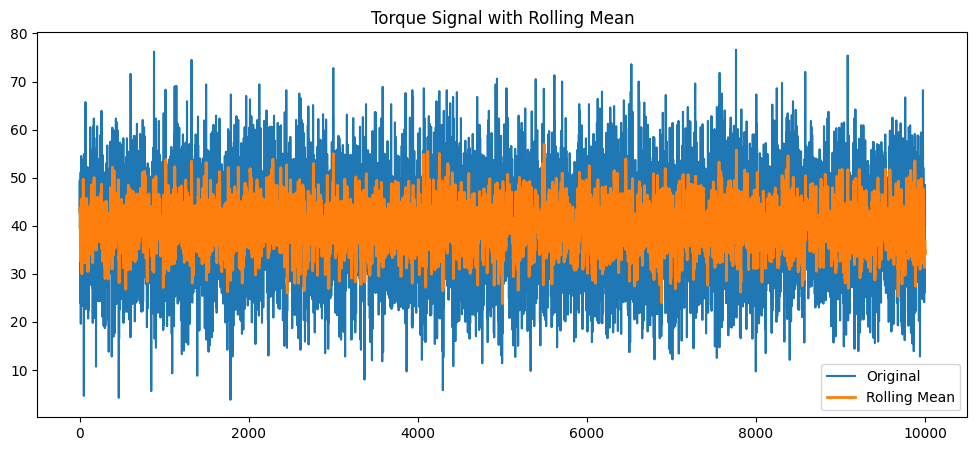

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(df["Torque [Nm]"],label="Original")

plt.plot(df["Torque [Nm]_RollingMean"],label="Rolling Mean",linewidth=2)

plt.legend()

plt.title("Torque Signal with Rolling Mean")

plt.show()

In [ ]:
df.to_csv("week1_AI4I2020.zip",index=False)

print("Week 1 Completed Successfully")

Week 1 Completed Successfully
